In [7]:
from __future__ import print_function

#import click
import serial
import time
import os.path as op
import os
import numpy as np
import threading
from collections import deque
import traceback
import struct
import csv


class WriteThread(threading.Thread):

    def __init__(self, output):

        assert output is not None

        super(WriteThread, self).__init__()

        if isinstance(output, str):

            output = op.expanduser(output)

            if op.isdir(output):
                # directory
                if not op.exists(output):
                     os.makedirs(output)
                of = op.join(output, 'imu_data3.csv')
            else:
                # file
                output_dir = op.split(output)[0]
                if not op.exists(output_dir):
                    os.makedirs(output_dir)
                of = output
        else:
            # stream etc
            of = output

        self.output = output
        self.file = of
        self.lock = threading.Lock()
        self.should_exit = False
        self.data = deque()
    def append(self, x):

        with self.lock:
            self.data.append(x)

    def stop(self):

        with self.lock:
            self.should_exit = True

    def run(self):
        with open(self.file, 'a') as f:
                line = None
                with self.lock:
                    if len(self.data) > 0:
                        line = self.data.popleft()

                if line is not None:
                    f.write(','.join([str(x) for x in line]) + '\n')
                else:
                    time.sleep(.01)

                    
   



# @click.command()
# @click.option('--device', '-d', default='COM8')
# @click.option('--baudrate', '-b', default=115200)
# @click.option('--output', '-o', default=r'D:\Documents\GitHub\R_Project\PPP\codebook')
# @click.option('--print-to-terminal', '-t', is_flag=True)
# @click.option('--skip-lines', '-S', is_flag=True)
# @click.option('--sync-signal', '-s', is_flag=True)


def convert_readbytes(record):
    readline=[]
    counts= str(struct.unpack('L',record[60:64])[0])
    readline.append(counts)
    ts=str(struct.unpack('L',record[64:68])[0])
    readline.append(ts)
    accx = str(round(struct.unpack('f',record[:4])[0],7))
    readline.append(accx)
    accy = str(round(struct.unpack('f',record[4:8])[0],7))
    readline.append(accy)
    accz = str(round(struct.unpack('f',record[8:12])[0],7))
    readline.append(accz)
    geox = str(round(struct.unpack('f',record[12:16])[0],7))
    readline.append(geox)
    geoy = str(round(struct.unpack('f',record[16:20])[0],7))
    readline.append(geoy)
    geoz= str(round(struct.unpack('f',record[20:24])[0],7))
    readline.append(geoz)
    magx= str(round(struct.unpack('f',record[24:28])[0],7))
    readline.append(magx)
    magy= str(round(struct.unpack('f',record[28:32])[0],7))
    readline.append(magy)
    magz= str(round(struct.unpack('f',record[32:36])[0],7))
    readline.append(magz)
    Roll= str(round(struct.unpack('f',record[36:40])[0],7))
    readline.append(Roll)
    Yaw= str(round(struct.unpack('f',record[40:44])[0],7))
    readline.append(Yaw)
    Pitch= str(round(struct.unpack('f',record[44:48])[0],7))
    readline.append(Pitch)
    linearaccx= str(round(struct.unpack('f',record[48:52])[0],7))
    readline.append(linearaccx)
    linearaccy= str(round(struct.unpack('f',record[52:56])[0],7))
    readline.append(linearaccy)
    linearaccz= str(round(struct.unpack('f',record[56:60])[0],7))
    readline.append(linearaccz)
     
    return readline
def cli(ser, output, print_to_terminal, skip_lines,sync_signal):

        write_thread = WriteThread(output)
        write_thread.start()
        time.sleep(.1)
        t0 = time.time()
        counter = 0
        #ser.reset_input_buffer()
        time.sleep(4)
        while True:
            try:    
                ser.write(b'h')
                while ser.inWaiting() < 69:
                    pass
                
                aline = ser.read(69)
                    # each line starts with a ">" and ends with a "<"
                    # as openframeworks serial used in the open-ephys
                    # GUI does not have a proper readline function.
                    # we don't need it here so we can ignore them.
                    
                        # values contains:
                        # status, index, ts, ax, ay, az, gx, gy, gz, mx, my, mz
                        # however, we will throw away the index and status
                        # values
                if aline[0]==97:
                    line=aline[1:]
                    readline=convert_readbytes(line)
                    write_thread.append(readline[:])
                    write_thread.run()
                    counter += 1
                else:
                    pass
                if print_to_terminal:
                    if  not skip_lines or (counter % 150 == 0):
                            print(*readline, sep = ", ",end="\n") 



                if counter % 200 == 0:
                    # this should show the frame rate every 1-2 seconds
                    now = time.time()
                    #print("fps:", 200. / (now - t0))
                    t0 = now

            except KeyboardInterrupt:
                break

            except BaseException:
                # print information about potential problems, e.g., partially transmitted data
                traceback.print_exc()

        # stop data acquisition
        ser.write(b"1\n")

        if write_thread is not None:
            write_thread.stop()
            write_thread.run()
if __name__ == '__main__':


    output=r'C:\Users\Cornell\Desktop\PP'
    device="COM5"
    baudrate=115200
    # ser=serial.Serial( device,baudrate,timeout=1)
    write_thread = WriteThread(output)
    ser=serial.Serial( device,baudrate,timeout=1)
    print('start calibration')
    time.sleep(4)
    #read calibration stuffs
    ser.write(b'c')
    while True:
        try:
            line = ser.readline().strip()
            marker= [str(u) for u in line.split(b",")]
            if len(line) > 0:
                if marker[0][2]=='>':
                   line=line[1:-1]
                   print(line)
                   values = [float(x) for x in line.split(b",")]
                   # print(values)
                   write_thread.append(values[:])  
                   write_thread.run()   
                   ser.flushInput()
                   ser.flushOutput()      
                   break   
                else:
                   print(line)            
        except KeyboardInterrupt:
            break            
    print_to_terminal=True
    skip_lines=True
    sync_signal=True

start calibration
b'Accel Gyro calibration will start in 5sec.'
b'Please leave the device still on the flat plane.'
b'Mag calibration will start in 5sec.'
b'Please Wave device in a figure eight until done.'
b'Mag Factory Calibration Values:'
b'X-Axis sensitivity offset value 1.21'
b'Y-Axis sensitivity offset value 1.22'
b'Z-Axis sensitivity offset value 1.17'
b'Mag Calibration: Wave device in a figure eight until done!'
b'mag x min/max:'
b'-495'
b'1612'
b'mag y min/max:'
b'-238'
b'751'
b'mag z min/max:'
b'-463'
b'854'
b'Mag Calibration done!'
b'AK8963 mag biases (mG)'
b'1016.41, 467.81, 342.63'
b'AK8963 mag scale (mG)'
b'0.69, 1.47, 1.15'
b'Mag Factory Calibration Values:'
b'X-Axis sensitivity offset value 1.21'
b'Y-Axis sensitivity offset value 1.22'
b'Z-Axis sensitivity offset value 1.17'
b'-2.55,2.83,-6.76,7.01,-4.08,0.25,1016.41,467.81,342.63,0.69,1.47,1.15'


In [8]:
print("start recording")
cli(ser, output ,print_to_terminal, skip_lines, sync_signal)

start recording
260362, 149, 0.34375, 0.4697266, -0.8041992, 128.6010742, -4.2724609, -102.0507812, -793.1533813, -262.9728699, -771.6004028, 145.355835, 12.1204376, 57.4116745, 0.8995558, 0.2597592, 0.0001599
262532, 299, 0.4130859, 0.7807617, -0.581543, -9.0942383, -4.2114258, 7.6904297, -818.3328247, -332.7411804, -686.9863281, 129.6520691, 21.3356647, 46.2398758, 1.1302521, 0.4169305, 0.0128471
264556, 449, 0.0327148, 0.7749023, -0.6806641, 1.5869141, 1.6479492, -2.6855469, -823.3687744, -402.5095215, -650.7230225, 135.505127, 4.8679461, 117.1182556, 0.7310324, 0.6900429, 0.0300763
266637, 599, 0.3886719, 0.8413086, -0.3041992, -10.3149414, -29.8461914, 10.925293, -849.8071289, -356.8917542, -515.7433472, 117.2033081, 20.7836113, 63.9293747, 1.2201867, 0.4864691, 0.1232022
268816, 749, 0.0532227, 0.8886719, -0.6450195, -58.5327148, 42.1142578, -12.878418, -828.4046021, -322.0075989, -666.8399658, 131.0609894, 19.7754345, 56.4220963, 0.7627661, 0.5503374, -0.0268952
270939, 899, 0.1

Empty DataFrame
Columns: [34.41, 33.47, 8.34, 6.92, 3.49, 8.98, -336.52, 302.69, -1511.88, 1.27, 1.51, 0.64]
Index: []
Series([], Name: -1511.88, dtype: object)
Series([], Name: 1.27, dtype: object)
Series([], Name: 1.51, dtype: object)


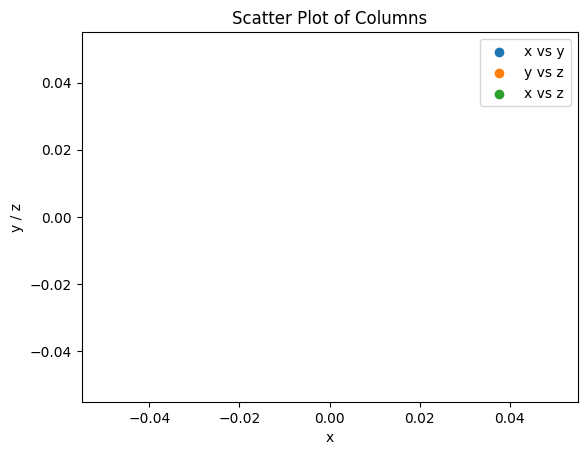

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
data_path=r'C:\Users\Cornell\Desktop\PP\imu_data3.csv'
# Read the CSV file
df = pd.read_csv(data_path)
print(df)
x = df.iloc[0:,8]  # Column 12
y = df.iloc[0:, 9]  # Column 13
z = df.iloc[0:, 10]  # Column 14
print(x)
print(y)
print(z)
plt.scatter(x, y, label='x vs y')
plt.scatter(y, z, label='y vs z')
plt.scatter(x, z, label='x vs z')
plt.xlabel('x')
plt.ylabel('y / z')
plt.title('Scatter Plot of Columns')
plt.legend()

# Display the plot
plt.show()